### 1. Importações

In [71]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Carregamento dos dados

In [7]:
df = pd.read_parquet("d:/FIAP/Engenharia de Machine Learning/Fase 3/tech_challenge_3/data/processed/flights_processed.parquet")
pd.set_option('display.max_columns', None) 
df.head() #ou df.sample() para ver dados aleatórios

,AIRLINE,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIRPORT,CITY,STATE,LATITUDE,LONGITUDE,DATE,HOUR,IS_DELAYED,IS_SHORT_DISTANCE,IS_MEDIUM_DISTANCE,IS_LONG_DISTANCE,IS_MORNING,IS_AFTERNOON,IS_NIGHT,IS_HOLIDAY,IS_WINTER,IS_SPRING,IS_SUMMER,IS_FALL
0,AS,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,-11.0,205.0,1448,430,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619,2015-01-01,0,0,0,1,0,1,0,0,1,1,0,0,0
1,AA,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,-8.0,280.0,2330,750,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,2015-01-01,0,0,0,0,1,1,0,0,1,1,0,0,0
2,US,2015,1,1,4,US,840,N171US,SFO,CLT,20,-2.0,286.0,2296,806,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,2015-01-01,0,0,0,0,1,1,0,0,1,1,0,0,0
3,AA,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,-5.0,285.0,2342,805,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,2015-01-01,0,0,0,0,1,1,0,0,1,1,0,0,0
4,AS,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,-1.0,235.0,1448,320,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931,2015-01-01,0,0,0,1,0,1,0,0,1,1,0,0,0


In [8]:
print("Shape do dataset:")
print(df.shape)

print("\nInformações gerais:")
print(df.info())

Shape do dataset:
(5226569, 34)

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 5226569 entries, 0 to 5226568
Data columns (total 34 columns):
 #   Column               Dtype         
---  ------               -----         
 0   AIRLINE              category      
 1   YEAR                 int16         
 2   MONTH                int8          
 3   DAY                  int8          
 4   DAY_OF_WEEK          int8          
 5   AIRLINE_CODE         str           
 6   FLIGHT_NUMBER        int32         
 7   TAIL_NUMBER          category      
 8   ORIGIN_AIRPORT       str           
 9   DESTINATION_AIRPORT  category      
 10  SCHEDULED_DEPARTURE  int16         
 11  DEPARTURE_DELAY      float32       
 12  SCHEDULED_TIME       float32       
 13  DISTANCE             int16         
 14  SCHEDULED_ARRIVAL    int16         
 15  AIRPORT              str           
 16  CITY                 str           
 17  STATE                str           
 18  LATITUDE            

### 3. Análise exploratória

1. Voos de algum período (manha/tarde/noite) atrasam mais? R: manhã (0h-5h)
2. Voos mais longos atrasam mais?
4. Companhias aéreas específicas atrasam mais? R: sim
5. Existe uma rota que atrasa mais? 
6. Existe um aeroporto que atras mais? R:
7. Existe sazonalidade? R:
8. Os dados estão balanceados? ou existe mais registro de aeroportos/regioes específicas?
9. Quais aeroportos são mais críticos em relação a atrasos? 
10. Que características aumentam a chance de atraso em um voo? 
11. Os atrasos são mais comuns em certos dias da semana ou horários? 
12. É possível agrupar aeroportos com perfis semelhantes? 
13. Até que ponto conseguimos prever atrasos com base no histórico e contexto do voo?

**Itens obrigatórios:**

1. [OK] Investigue os dados com estatísticas descritivas. 
2. [OK] Crie visualizações que trazem insights. 
3. [OK] Trate valores ausentes de forma adequada.
4. [OK] Criar variáveis derivadas (ex.: período do dia, feriados, estações do ano). 
5. [OK] Analisar atrasos por aeroporto, companhia ou estado. 
6. Criar mapas geográficos de rotas e atrasos.
7. Identificar padrões sazonais ou horários críticos.  
8. Modelagem supervisionada (mínimo um modelo) --> **Classificação**: prever se um voo vai atrasar ou não OU **Regressão**: prever quanto tempo o atraso vai durar. Compare pelo menos dois algoritmos diferentes e avalie com métricas adequadas.   
9. Modelagem não supervisionada (mínimo uma abordagem):
    * Use clusterização (ex.: agrupar rotas, aeroportos ou companhias aéreas) ou redução de dimensionalidade (ex.: PCA). 
    * Mostre os resultados em gráficos e faça a interpretação. 
    * Compartilhe as principais conclusões. 
    * Discuta as limitações dos modelos. 
    * Proponha melhorias e próximos passos


In [9]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,LATITUDE,LONGITUDE,DATE,HOUR,IS_DELAYED,IS_SHORT_DISTANCE,IS_MEDIUM_DISTANCE,IS_LONG_DISTANCE,IS_MORNING,IS_AFTERNOON,IS_NIGHT,IS_HOLIDAY,IS_WINTER,IS_SPRING,IS_SUMMER,IS_FALL
count,5226569.0,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5226569,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06,5.226569e+06
mean,2015.0,6.229003e+00,1.569437e+01,3.925540e+00,2.169252e+03,1.329546e+03,9.699213e+00,1.420431e+02,8.254414e+02,1.493205e+03,3.662372e+01,-9.557288e+01,2015-06-22 21:52:18.347854,1.302853e+01,1.893638e-01,3.622103e-01,5.013553e-01,1.364344e-01,4.132520e-01,3.677305e-01,2.190175e-01,2.693660e-02,2.535411e-01,2.846856e-01,2.905256e-01,1.712477e-01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.800000e+01,3.100000e+01,1.000000e+00,1.348345e+01,-1.766460e+02,2015-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,3.000000e+00,8.000000e+00,2.000000e+00,7.290000e+02,9.160000e+02,-5.000000e+00,8.600000e+01,3.730000e+02,1.110000e+03,3.289595e+01,-1.119778e+02,2015-03-29 00:00:00,9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,6.000000e+00,1.600000e+01,4.000000e+00,1.681000e+03,1.325000e+03,-1.000000e+00,1.230000e+02,6.510000e+02,1.520000e+03,3.724433e+01,-9.025803e+01,2015-06-18 00:00:00,1.300000e+01,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,8.000000e+00,1.740000e+02,1.067000e+03,1.918000e+03,4.078839e+01,-8.168786e+01,2015-09-06 00:00:00,1.700000e+01,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.320000e+03,2.359000e+03,1.988000e+03,7.180000e+02,4.983000e+03,2.400000e+03,7.128545e+01,-6.479856e+01,2015-12-31 00:00:00,2.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,0.0,3.377496e+00,8.765637e+00,1.990376e+00,1.758272e+03,4.840856e+02,3.739250e+01,7.537698e+01,6.088503e+02,5.077077e+02,6.008449e+00,1.818934e+01,NaN,4.828016e+00,3.917974e-01,4.806392e-01,4.999982e-01,3.432493e-01,4.924173e-01,4.821875e-01,4.135805e-01,1.618982e-01,4.350380e-01,4.512646e-01,4.540050e-01,3.767253e-01


###  Balanceamento do target

* Os dados estão numa proporção 80/20. 
* É esperado que os dados estejam desbalanceados, porque a maioria dos voos não atrasa.
* O problema é que um modelo ingênuo poderia prever sempre 0 e ainda ter cerca de 80% de acurácia. (e, por isso, accuracy sozinha não é boa métrica)
* Com 5,2 milhões de linhas, já há muitos exemplos da classe minoritária (cerca de 1 milhão).

In [12]:
print("\nDistribuição do target:")
print(df["IS_DELAYED"].value_counts())

print("\nDistribuição percentual:")
print(df["IS_DELAYED"].value_counts(normalize=True) * 100)


Distribuição do target:
IS_DELAYED
0    4236846
1     989723
Name: count, dtype: int64

Distribuição percentual:
IS_DELAYED
0    81.063619
1    18.936381
Name: proportion, dtype: float64


In [89]:
print("O maior atraso foi de ", max(df["DEPARTURE_DELAY"]), "minutos.")

O maior atraso foi de  1988.0 minutos.


* 243 casos em ~5,2 milhões de voos com atraso > 1000 min (~0,005%).

Para um problema de regressão, poderia ser um problema. Mas para o caso de classificação, vamos manter os casos extramos.

In [93]:
df[df["DEPARTURE_DELAY"] > 1000]["DEPARTURE_DELAY"].describe()

count     243.000000
mean     1190.032959
std       175.733917
min      1001.000000
25%      1057.500000
50%      1140.000000
75%      1257.500000
max      1988.000000
Name: DEPARTURE_DELAY, dtype: float64

In [95]:
extreme_delays = df[df["DEPARTURE_DELAY"] > 1000]

extreme_delays["AIRLINE_CODE"].value_counts()

AIRLINE_CODE
AA    143
DL     54
UA     15
MQ     10
HA      7
OO      7
EV      5
F9      1
B6      1
Name: count, dtype: int64

In [97]:
extreme_delays["ORIGIN_AIRPORT"].value_counts()

ORIGIN_AIRPORT
HNL    15
SFO    12
SJU     9
JFK     8
ORD     8
       ..
SLC     1
MBS     1
EVV     1
OAK     1
MGM     1
Name: count, Length: 89, dtype: int64

In [104]:
extreme_delays["HOUR"].value_counts()

HOUR
13    29
11    23
17    21
12    20
14    19
16    18
15    17
18    13
8     12
7     12
19    11
6     10
9     10
5      9
10     7
21     5
20     4
1      1
22     1
23     1
Name: count, dtype: int64

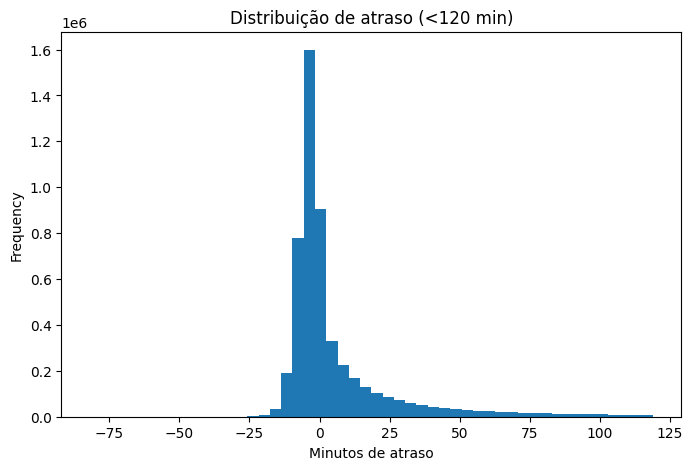

In [85]:
df[df["DEPARTURE_DELAY"] < 120]["DEPARTURE_DELAY"].plot(
    kind="hist",
    bins=50,
    figsize=(8,5)
)

plt.title("Distribuição de atraso (<120 min)")
plt.xlabel("Minutos de atraso")
plt.show()

### Atraso por companhia aérea

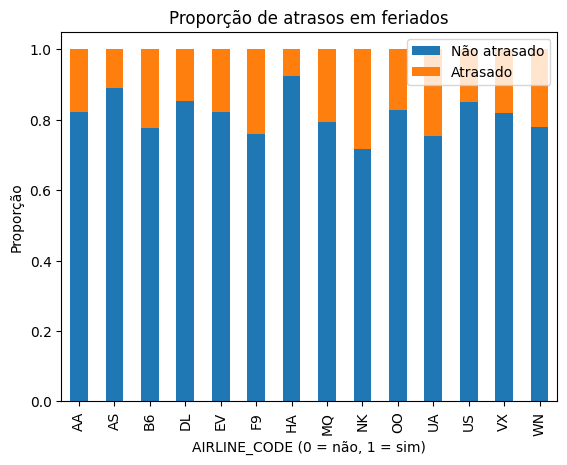

In [61]:
data = pd.crosstab(
    df["AIRLINE_CODE"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True)

plt.title("Proporção de atrasos em feriados")
plt.xlabel("AIRLINE_CODE (0 = não, 1 = sim)")
plt.ylabel("Proporção")
plt.legend(["Não atrasado", "Atrasado"])
plt.show()

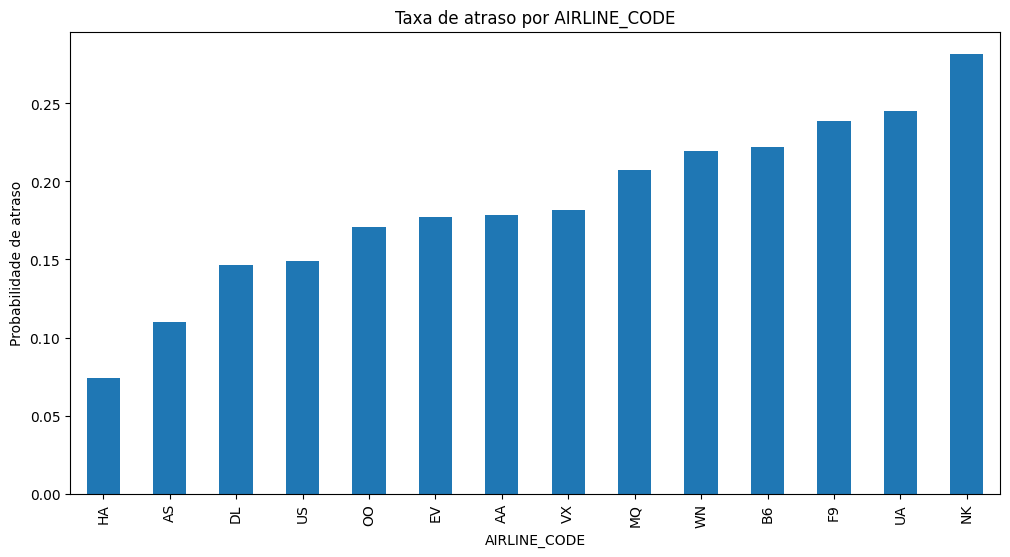

In [60]:
delay_by_state = df.groupby("AIRLINE_CODE")["IS_DELAYED"].mean().sort_values()
delay_by_state.plot(kind="bar", figsize=(12,6))
plt.title("Taxa de atraso por AIRLINE_CODE")
plt.xlabel("AIRLINE_CODE")
plt.ylabel("Probabilidade de atraso")
plt.show()

### Atraso por aeroporto de origem

In [58]:
df.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending=False)

ORIGIN_AIRPORT
ADK    0.443182
GST    0.407895
ILG    0.389474
MVY    0.317073
STC    0.311688
         ...   
EKO    0.052224
PIH    0.046012
CNY    0.029268
LWS    0.028912
VEL    0.025000
Name: IS_DELAYED, Length: 319, dtype: float64

### Atraso por estado / região

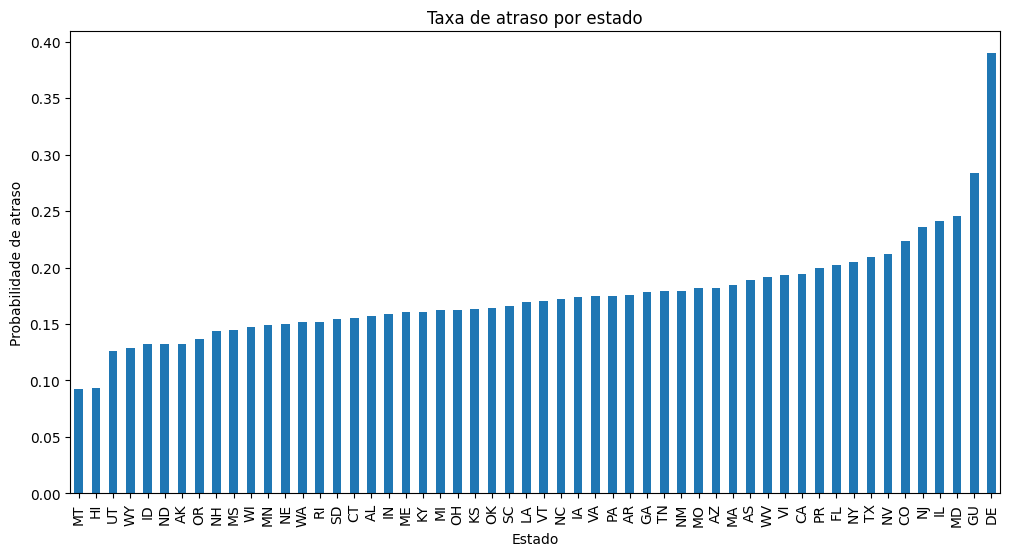

In [42]:
delay_by_state = df.groupby("STATE")["IS_DELAYED"].mean().sort_values()
delay_by_state.plot(kind="bar", figsize=(12,6))
plt.title("Taxa de atraso por estado")
plt.xlabel("Estado")
plt.ylabel("Probabilidade de atraso")
plt.show()

### Atraso ao longo do dia

* Voos atrasam menos de manhã (5h-12h)) se comparado com tarde e noite 
* Voos de madrugada são os que mais atrasam (0h-4h)

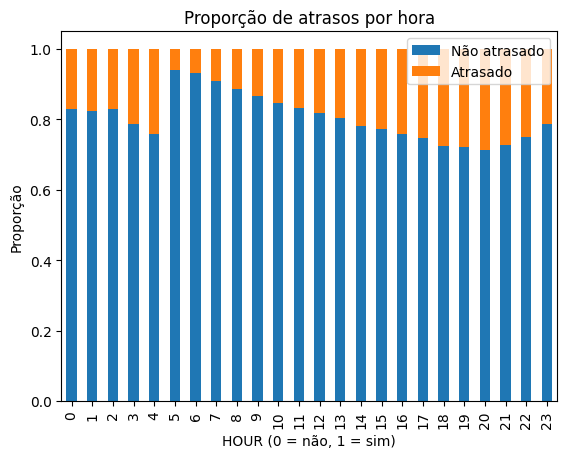

In [62]:
data = pd.crosstab(
    df["HOUR"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True)

plt.title("Proporção de atrasos por hora")
plt.xlabel("HOUR (0 = não, 1 = sim)")
plt.ylabel("Proporção")
plt.legend(["Não atrasado", "Atrasado"])
plt.show()

### Atraso por distância

* Não parece ter relação com atraso

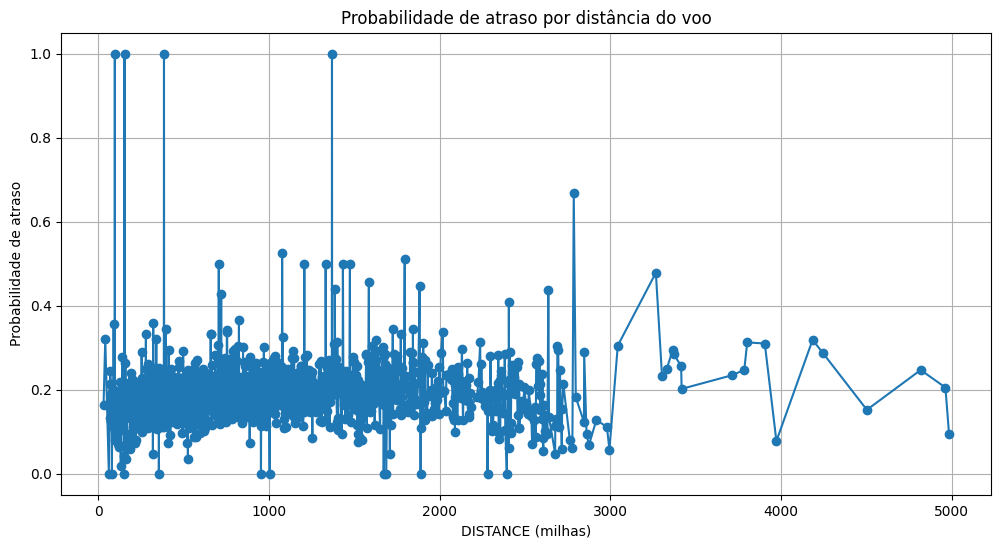

In [107]:
# Calcular taxa de atraso por distância
delay_by_distance = df.groupby("DISTANCE")["IS_DELAYED"].mean().sort_index()

# Plotar gráfico de linhas
delay_by_distance.plot(kind="line", figsize=(12,6), marker='o')  # marker opcional para visualizar pontos

plt.title("Probabilidade de atraso por distância do voo")
plt.xlabel("DISTANCE (milhas)")
plt.ylabel("Probabilidade de atraso")
plt.grid(True)  # opcional, deixa o gráfico mais legível
plt.show()

### Atraso em feriados

* Não parece ter grande relação

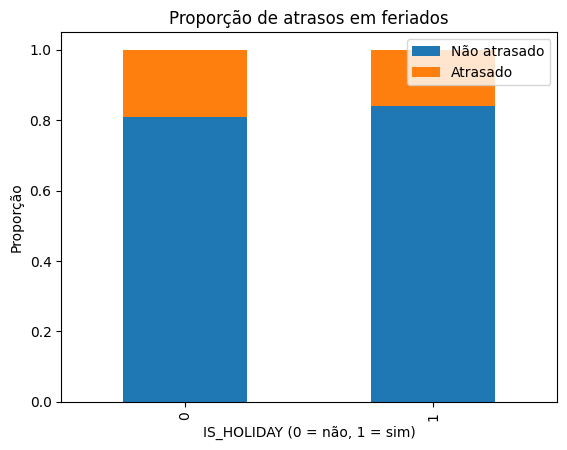

In [29]:
data = pd.crosstab(
    df["IS_HOLIDAY"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True)

plt.title("Proporção de atrasos em feriados")
plt.xlabel("IS_HOLIDAY (0 = não, 1 = sim)")
plt.ylabel("Proporção")
plt.legend(["Não atrasado", "Atrasado"])
plt.show()

### Atraso por estação do ano

* No inverno a taxa de atraso aumenta em relação ao não inverno
* primavera e verão parecem ser indiferentes
* No outono a taxa de atrasos reduzi.

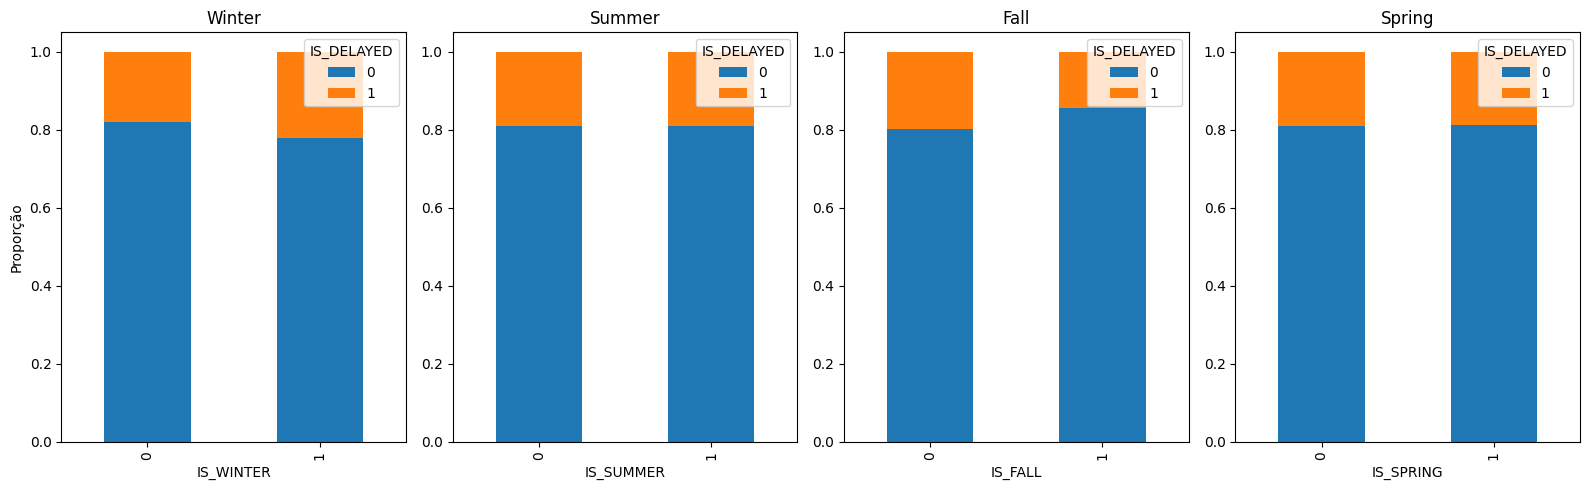

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(16,5))

# WINTER
data = pd.crosstab(
    df["IS_WINTER"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Winter")
axes[0].set_ylabel("Proporção")

# SUMMER
data = pd.crosstab(
    df["IS_SUMMER"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Summer")
axes[1].set_ylabel("")

# FALL
data = pd.crosstab(
    df["IS_FALL"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("Fall")
axes[2].set_ylabel("")

#SPRING
data = pd.crosstab(
    df["IS_SPRING"],
    df["IS_DELAYED"],
    normalize="index"
)

data.plot(kind="bar", stacked=True, ax=axes[3])
axes[3].set_title("Spring")
axes[3].set_ylabel("")


plt.tight_layout()
plt.show()

### Matriz de correlação

<Axes: >

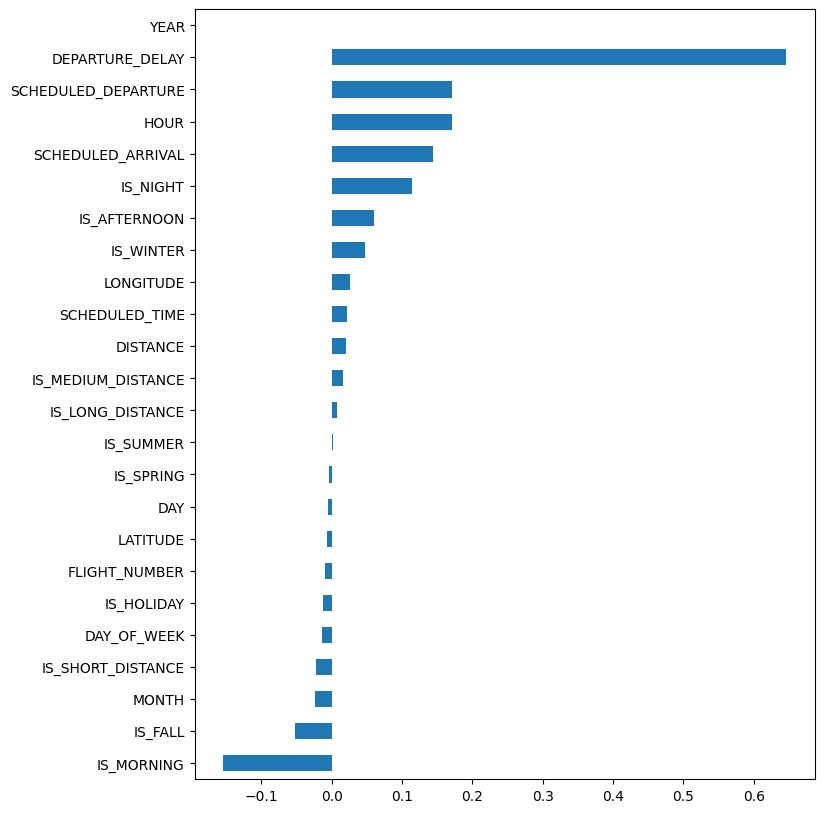

In [76]:
corr = df.corr(numeric_only=True)["IS_DELAYED"].drop("IS_DELAYED")
corr.sort_values().plot(kind="barh", figsize=(8,10))

In [77]:
corr = df.corr(numeric_only=True)["IS_DELAYED"].drop("IS_DELAYED")
corr = corr.sort_values()
corr

IS_MORNING            -0.154865
IS_FALL               -0.051869
MONTH                 -0.024199
IS_SHORT_DISTANCE     -0.022813
DAY_OF_WEEK           -0.013169
IS_HOLIDAY            -0.012927
FLIGHT_NUMBER         -0.010133
LATITUDE              -0.006041
DAY                   -0.005888
IS_SPRING             -0.003540
IS_SUMMER              0.001808
IS_LONG_DISTANCE       0.007615
IS_MEDIUM_DISTANCE     0.016701
DISTANCE               0.020488
SCHEDULED_TIME         0.022395
LONGITUDE              0.026396
IS_WINTER              0.046701
IS_AFTERNOON           0.059703
IS_NIGHT               0.114779
SCHEDULED_ARRIVAL      0.143554
HOUR                   0.170820
SCHEDULED_DEPARTURE    0.171169
DEPARTURE_DELAY        0.646608
YEAR                        NaN
Name: IS_DELAYED, dtype: float64

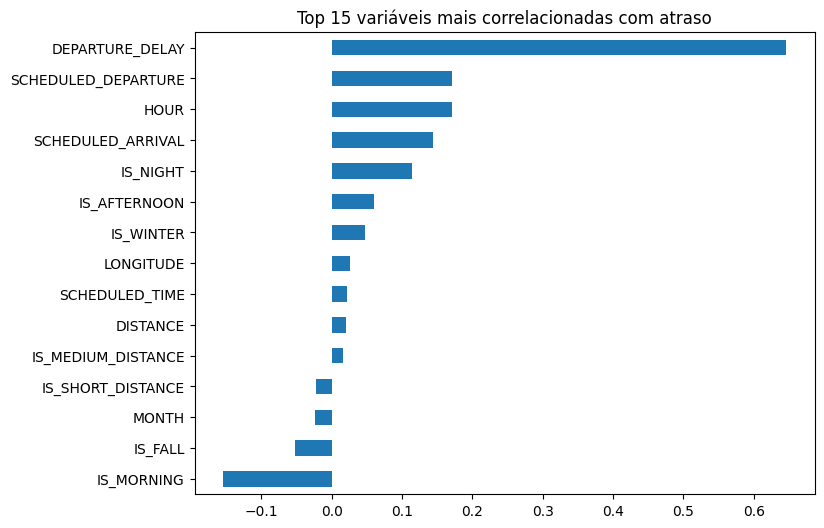

In [78]:
corr_sorted = corr.abs().sort_values(ascending=False)

top_features = corr_sorted.head(15).index

corr[top_features].sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 15 variáveis mais correlacionadas com atraso")
plt.show()

### Efeito cascata: acontece porque atrasos acumulam ao longo do dia:

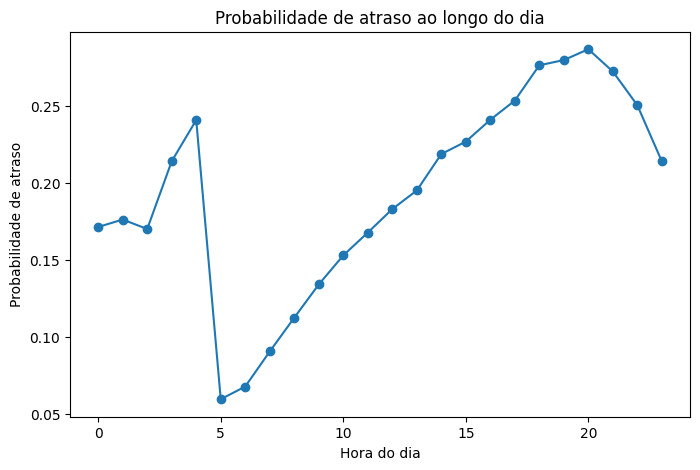

In [79]:
delay_by_hour = df.groupby("HOUR")["IS_DELAYED"].mean()

delay_by_hour.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Probabilidade de atraso ao longo do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Probabilidade de atraso")
plt.show()